# 12. Γεωεπεξεργασία ψηφιδωτών δεδομένων (rasterio)

Η βιβλιοθήκη [Rasterio](https://rasterio.readthedocs.io/en/stable/) αποτελεί μια από τις πιο διαδεδομένες βιβλιοθήκες για την ανάγνωση και εγγραφή ψηφιδωτών αρχείων (raster).
Είναι δομημένη πάνω στην βιβλιοθήκη GDAL (Geospatial Data Abstraction Library) και παρέχει πιο εύχρηστο τρόπο συγγραφής κώδικα στα πρότυπα που απαιτεί η Python (pythonic).

Ως προς τις δυνατότητες παρέχει ανάγνωση και εγγραφή ψηφιδωτών αρχείων, πρόσβαση στα μεταδεδομένα και τις ιδιότητές τους (πχ γεωγραφικό σύστημα αναφορά, διακριτική ικανότητα, πρόσβαση σε πολλαπλά κανάλια εικόνας). Επιπλέον συνδυάζεται άριστα με την βιβλιοθήκη [numpy](https://numpy.org/) και είναι συμβατή με βιβλιοθήκες για αλληλεπίδραση με διανυσματικά δεδομένα ([Shapely](https://shapely.readthedocs.io/), [GeoPandas](https://geopandas.org/), and [PyProj](https://pyproj4.github.io/pyproj/stable/) ενώ μέσω της βιβλιοθήκης [matplotlib](https://matplotlib.org/) δίνει την δυνατότητα οπτικοποίησης ψηφιδωτών δεδομένων. Ταυτόχρονα ένα από τα πλεονεκτήματά της είναι η δυνατότητα ανάγνωσης μεγάλων δεδομένων (block wise reading).


## Εγκατάσταση της βιβλιοθήκης, βασικές λειτουργίες
Η εγκατάσταση της βιβλιοθήκης `rasterio` εξαρτάται από το περιβάλλον εργασίας. Σε περίπτωση που το περιβάλλον εργασίας είναι το `conda` τότε η εγκατάσταση της `rasterio` από το κανάλι `conda-forge` γίνεται με την εντολή  `conda install -c conda-forge rasterio`. Για το `pip` χρησιμοποιείται η εντολή `pip install rasterio`. Περισσότερες λεπτομέρειες για την εγκατάσταση της βιβλιοθήκης αναφέρονται εδώ: https://rasterio.readthedocs.io/en/stable/installation.html

## Άνοιγμα αρχείου
Για το άνοιγμα ενός ψηφιδωτού αρχείου χρησιμοποιείται η μέθοδος `open` από την βιβλιοθήκη `rasterio`. Στην συνέχεια, στο object του αρχείου που έχει ανοίξει καλούμε την μέθοδο `read` η οποία διαβάζει τις τιμές των pixel από όλα τα κανάλια (bands) της εικόνας (ή από επιλεγμένα αν οριστεί index) και τα επισυνάπτει σε ένα numpy array. Η μέθοδος `read` δέχεται σαν παράμετρο είτε τον index του καναλίου που θέλουμε να ανοίξουμε είτε τίποτα οπότε και θα διαβάσει όλα τα κανάλια. Αξίζει να σημειωθεί ότι το index για το πρώτο κανάλι είναι το `1` και όχι το `0` όπως συνηθίζεται στην Python. Στο παρακάτω παράδειγμα χρησιμοποιείται η  `rasterio` για την ανάγνωση όλων των καναλιών μιας εικόνας LandSat8 σαν numpy array. 

In [2]:

import rasterio

# Source: Landsat 8-9 OLI/TIRS Collection 2 Level-2 Science Products 
# https://www.usgs.gov/centers/eros/science/usgs-eros-archive-landsat-archives-landsat-8-9-olitirs-collection-2-level-2
path = 'LC08_L2SP_183033_20250906_20250912_02_T1_SR_VOLOS.tif'

with rasterio.open(path) as src:
    data = src.read() # ανάγνωση όλων των καναλιών

Επιπλέον είναι δυνατή η ανάγνωση αρχείων που φιλοξενούνται διαδικτυακά ([Cloud Optimized GeoTIFF (COG)](https://cogeo.org/)). Ανεξάρτητα που είναι το αρχείο προς ανάγνωση (τοπικά ή απομακρυσμένα) είναι δυνατόν κατά την ανάγνωση να οριστεί ένα τμήμα του αρχείου μόνο. Το τμήμα αυτό μπορεί να οριστεί με δύο τρόπους. Είτε να οριστεί ένα υποσύνολο δίνοντας σαν αρχικό σημείο κατάτμησης το index του πάνω αριστερά pixel ενός bounding box και στην συνέχεια το πλάτος και το ύψος του πάλι σε pixels. Είτε ορίζοντας τις γεωγραφικές συντενταγμένες (στο προβολικό σύστημα του αρχείου) του bounding box που ενδιαφέρει τον χρήστη. Στο παρακάτω παράδειγμα δίνεται η ανάγνωση ενός αρχείου Cloud Optimized GeoTIFF (COG) μέσω του ορισμού bounding box σε γεωγραφικές συντεταγμένες αντίστοιχες με το προβολικό σύστημα του αρχείου προς ανάγνωση.

In [7]:
import rasterio
from rasterio.env import Env

env = Env(
    GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
    CPL_VSIL_CURL_ALLOWED_EXTENSIONS=".tif",
    GDAL_HTTP_TIMEOUT=3600,
    GDAL_HTTP_MAX_RETRY=5,
)

env.__enter__()

NameError: name 'nb' is not defined

In [5]:
from rasterio.windows import from_bounds
url = 'https://huggingface.co/datasets/leoliakos/LandSat8/resolve/main/LC08_L2SP_183033_20250906_20250912_02_T1_SR.tif'

# Συντεταγμένες για τον Βόλο. Οι συντεταγμένες δίνονται στο προβολικό σύστημα της εικόνας προς ανάγνωση.
left   = 632003
bottom = 4315978
right  = 717315
top    = 4395603

with rasterio.open(url) as ds:
    window = from_bounds(
        left=left,
        bottom=bottom,
        right=right,
        top=top,
        transform=ds.transform
    )
    data1 = ds.read(1, window=window) # ανάγνωση πρώτης μπάντας και σε γεωγραφικό υποσύνολο της εικόνας

Το object `data` είναι ένα numpy array το οπόιο μπορεί να οπτικοποιηθεί με την βοήθεια της βιβλιοθήκης numpy array.

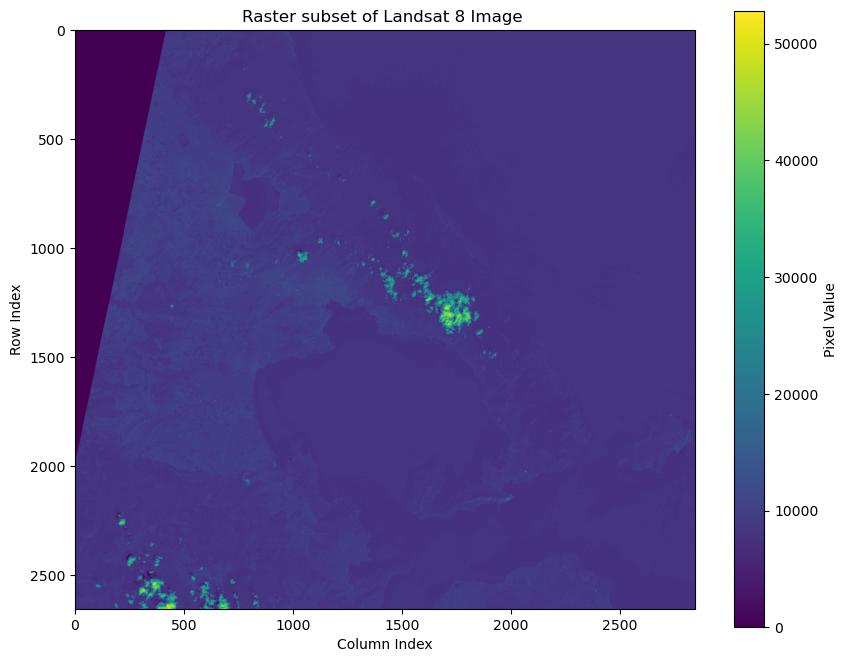

In [3]:
import matplotlib.pyplot as plt

# Οπτικοποίηση του 'data' array
plt.figure(figsize=(10, 8))
img = plt.imshow(data1, cmap='viridis')  # 'viridis': χρωματική παλέτα για συνεχή δεδομένα
plt.colorbar(img, label='Pixel Value') # υπόμνημα
plt.title("Raster subset of Landsat 8 Image ")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

Στο παρακάτω παράδειγμα γίνεται ανάγνωση τμήματος του αρχείου μέσω της ορισμού window (pixel έναρξης μέσω του ορισμού col_off και row_off και του πλάτους και ύψους).

In [4]:
from rasterio.windows import Window

with rasterio.open(url) as ds:
    window = Window(col_off=1500, row_off=2000, width=1000, height=1000)
    data2 = ds.read(1, window=window)

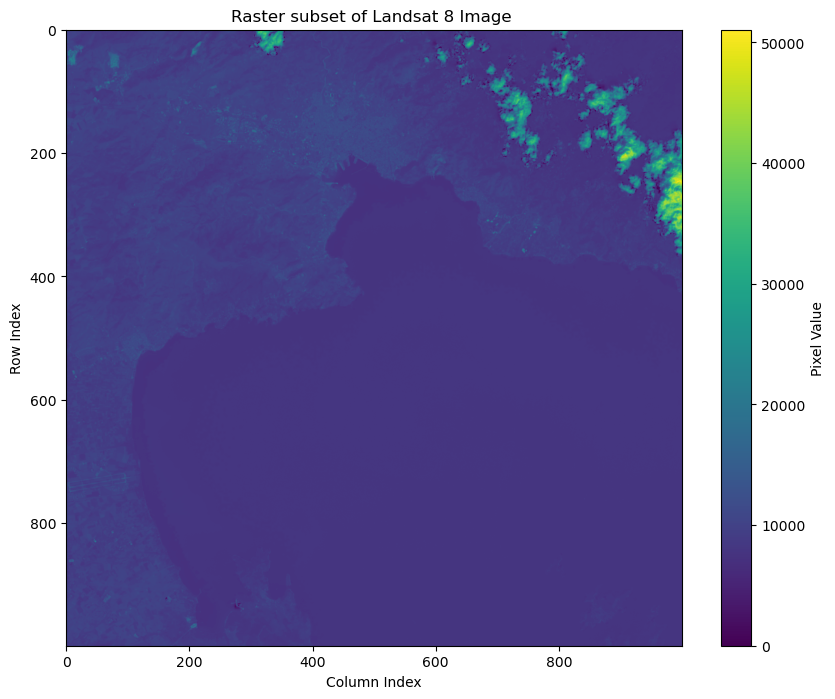

In [5]:
# Οπτικοποίηση του 'data' array
plt.figure(figsize=(10, 8))
img = plt.imshow(data2, cmap='viridis')  # 'viridis': χρωματική παλέτα για συνεχή δεδομένα
plt.colorbar(img, label='Pixel Value') # υπόμνημα
plt.title("Raster subset of Landsat 8 Image ")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.show()

 
 ## Ανάγνωση μεταδεδομένων

 

Όπως αναφέρθηκε κατά την ανάγνωση είναι δυνατόν να αγνοηθεί το index του καναλιού και κατά συνέπεια να αναγνωστούν όλα τα κανάλια της εικόνας:


In [6]:

with rasterio.open(url) as ds:
    window = from_bounds(
        left=left,
        bottom=bottom,
        right=right,
        top=top,
        transform=ds.transform
    )
    data_all_bands = ds.read(window=window) # ανάγνωση όλων των καναλιών και σε γεωγραφικό υποσύνολο της εικόνας

Από ένα ανοικτό αρχείο μέσω του `rasterio` μπορούμε να ανακτήσουμε χρήσιμες ιδιότητες για το raster. Για παράδειγμα μπορούμε να ανακτήσουμε το προβολικό σύστημα, τις διαστάσεις (width, height) του σε pixels, το bounding box και τον αριθμό των καναλιών. Επίσης, στην `rasterio`, το `meta` (ή `profile`) είναι ένα λεξικό μεταδεδομένων που περιγράφει διάφορες ιδιότητες για το raster αρχείο. Η ιδιότητα `profile` παρέχει πιο πολλές λεπτομέρειες αναφορικά με τις ιδιότητες του αρχείου.



In [6]:
with rasterio.open(url) as ds:
    window = from_bounds(
        left=left,
        bottom=bottom,
        right=right,
        top=top,
        transform=ds.transform
    )
    data_all_bands = ds.read(window=window) # ανάγνωση όλων των καναλιών και σε γεωγραφικό υποσύνολο της εικόνας# Print
    
    print(f"CRS: {ds.crs}")
    print(f"Shape (rows, cols): ({ds.height}, {ds.width})")
    print(f"Bounds: {ds.bounds}")
    print(f"Number of bands: {ds.count}")
    print(f"Cell resolution (x, y): {ds.res}")
    print('-'*50)
    print(ds.meta)
    print('-'*50)
    print(ds.profile)

CRS: EPSG:32634
Shape (rows, cols): (7731, 7601)
Bounds: BoundingBox(left=608385.0, bottom=4192785.0, right=836415.0, top=4424715.0)
Number of bands: 7
Cell resolution (x, y): (30.0, 30.0)
--------------------------------------------------
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7601, 'height': 7731, 'count': 7, 'crs': CRS.from_epsg(32634), 'transform': Affine(30.0, 0.0, 608385.0,
       0.0, -30.0, 4424715.0)}
--------------------------------------------------
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7601, 'height': 7731, 'count': 7, 'crs': CRS.from_epsg(32634), 'transform': Affine(30.0, 0.0, 608385.0,
       0.0, -30.0, 4424715.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}


## Αλλαγή προβολικού συστήματος

Η βιβλιοθήκη rasterio δίνει την δυνατότητα μετατροπής του προβολικού συστήματος ενός αρχείου σε ένα άλλο (reprojection).
Αν και δεν είναι ιδιαίτερα εύχρηστη ως προς την διαδικασία σε σχέση με άλλες βιβλιοθήκες ή λογισμικά ωστόσο δίνει μεγάλη ευλιξία στον χρήστη.

In [27]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import math

src_path  = 'LC08_L2SP_183033_20250906_20250912_02_T1_SR_VOLOS.tif'
dst_path = "Volos_2100.tif"
dst_crs = "EPSG:2100"  # προβολικό σύστημα αναφοράς που θα γίνει το reprojection 
target_res = 30  # ανάλυση (resolution) στο νέο σύστημα αναφοράς


with rasterio.open(src_path) as src:
    # 1. Υπολογισμός του default transform για το target CRS
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    # 2. τροποποίηση του transform ώστε να οριστεί η ανάλυση στα 30m ακριβώς
    scale_x = target_res / transform.a
    scale_y = target_res / abs(transform.e)
    
    width = math.ceil(width * scale_x)
    height = math.ceil(height * scale_y)
    
    # δημιουργία νέου transform object (με ανάλυση 30m)
    transform = rasterio.transform.Affine(
        target_res, transform.b, transform.c,
        transform.d, -target_res, transform.f
    )

    # 3. metadata για το εξαγώγιμο αρχείο
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height,
        "nodata": src.nodata
    })

    # 4. εφαρμογή Reproject
    with rasterio.open(dst_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear  # or nearest  για κατηγορικά δεδομένα
            )





## Αποκοπή εικόνας με βάση διανυσματικά δεδομένα  (πχ με Shapely/GeoPandas integration) 


Επιπλέον υπάρχει η λειτουργία της αποκοπής (crop) και κάλυψη (mask) μιας εικόνας με βάση ένα διανυσματικό αρχείο. Στο παρακάτω παράδειγμα η εικόνα LandSat αποκόπτεται και γίνεται mask στα όρια του Δήμου Βόλου.

In [29]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd


vector_path = "data/OTA/0adb0521-2223-43cd-96d3-d816ad7a193c.shp"
output_path = "LandSat8_Volos_clipped.tif"

# 1. Read shapefile with GeoPandas
gdf = gpd.read_file(vector_path)
gdf = gdf[gdf['NAME_LATIN']=='D. BOLOY']


# 2. Ensure CRS matches raster CRS
with rasterio.open(url) as src:
    window = from_bounds(
        left=left,
        bottom=bottom,
        right=right,
        top=top,
        transform=ds.transform
    )

    
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)

    # Convert geometries to GeoJSON-like dicts
    geoms = gdf.geometry.values  # Shapely geometries
    geoms = [geom.__geo_interface__ for geom in geoms]

    # 3. Clip & mask raster
    out_image, out_transform = mask(src, geoms, crop=True)

    # 4. Update metadata for output
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": src.nodata
    })

# 5. Write the clipped raster
with rasterio.open(output_path, "w", **out_meta) as dst:
    dst.write(out_image)

print(f"✔ Clipped raster saved to {output_path}")


✔ Clipped raster saved to LandSat8_Volos_clipped.tif


## Resampling (nearest, bilinear, cubic)

In [33]:
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_origin
import math


src_path = "Volos_2100.tif"
dst_path = "Volos_2100_100m.tif"

target_res = 100  # 100 meters per pixel

with rasterio.open(src_path) as src:
    # 1. Calculate new width and height based on target resolution
    width = math.ceil((src.bounds.right - src.bounds.left) / target_res)
    height = math.ceil((src.bounds.top - src.bounds.bottom) / target_res)

    # 2. Create new affine transform
    transform = from_origin(src.bounds.left, src.bounds.top, target_res, target_res)

    # 3. Read resampled data
    data_resampled = src.read(
        out_shape=(src.count, height, width),
        resampling=Resampling.bilinear  # use nearest for categorical data
    )

    # 4. Update metadata
    kwargs = src.meta.copy()
    kwargs.update({
        "height": height,
        "width": width,
        "transform": transform,
        "nodata": src.nodata
    })

# 5. Write resampled raster
with rasterio.open(dst_path, "w", **kwargs) as dst:
    dst.write(data_resampled)

print(f"✔ Raster resampled to 100m and saved as {dst_path}")



✔ Raster resampled to 100m and saved as Volos_2100_100m.tif


## Rescale Data

In [36]:
import rasterio
import numpy as np

# Paths
input_path = "Volos_2100.tif"
ndvi_path = "NDVI.tif"

# Landsat 8 bands for NDVI
# B4 = Red (Band 4), B5 = NIR (Band 5) 1-based index in Rasterio
RED_BAND = 4
NIR_BAND = 5

# Scale factor formula
def apply_sr(dn):
    return dn * 0.0000275 - 0.2

# Read multiband image
with rasterio.open(input_path) as src:
    meta = src.meta.copy()
    
    # Read RED and NIR bands
    red = src.read(RED_BAND).astype(np.float32)
    nir = src.read(NIR_BAND).astype(np.float32)
    
    # Apply scale factor
    red_sr = apply_sr(red)
    nir_sr = apply_sr(nir)
    
    # Handle nodata
    nodata = src.nodata
    if nodata is not None:
        mask = (red == nodata) | (nir == nodata)
    else:
        mask = np.zeros(red.shape, dtype=bool)
    
    # Calculate NDVI
    ndvi = np.where(
        ~mask,
        (nir_sr - red_sr) / (nir_sr + red_sr),
        np.nan
    )

# Update metadata for single-band output
meta.update({
    "count": 1,
    "dtype": "float32",
    "nodata": np.nan
})

# Write NDVI to GeoTIFF
with rasterio.open(ndvi_path, "w", **meta) as dst:
    dst.write(ndvi.astype(np.float32), 1)

print(f"✔ NDVI saved as {ndvi_path}")


✔ NDVI saved as NDVI.tif


## Apply mask